In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pickle
from sklearn.pipeline import Pipeline


df = pd.read_csv('data.csv') 
df = df.drop(columns=['id'], errors='ignore')
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

top_features = df.corr()['diagnosis'].sort_values(ascending=False).index[1:6].tolist()
print(f"Your Top 5 Selection Criteria: {top_features}")





X = df[top_features]
y = df['diagnosis']

# ده كله لتدريب الموديل
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)


#my Edit
#==========

final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

final_model.fit(X_train_scaled, y_train)

#==========


"""
    ده عشان يحفظ المودل في فايل خارجي عشان ميعدش العملية كل مرة وكمان يحفظ طريقة
    السكيل عشان يعمل نفس الطريقة مع الانبوتس الي داخلة
"""
# with open('cancer_model.pkl', 'wb') as f:
#     pickle.dump(model, f)
# with open('scaler.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

#MY EDIT:
#==============

with open('final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('selected_features.pkl', 'wb') as f:
    pickle.dump(top_features, f)


selected_features_df = X_train.copy()
selected_features_df["diagnosis"] = y_train
selected_features_df["diagnosis"] = selected_features_df["diagnosis"].map({
    0: "Benign",
    1: "Malignant"
})


with open('selected_features_df.pkl', 'wb') as f:
    pickle.dump(selected_features_df, f)

#==============





Your Top 5 Selection Criteria: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean']


In [2]:
def predict_probability(inputs):
    model = pickle.load(open('cancer_model.pkl', 'rb'))
    scaler = pickle.load(open('scaler.pkl', 'rb'))
    
    inputs_scaled = scaler.transform([inputs])
    probability = model.predict_proba(inputs_scaled)[0][1] * 100
    return probability

def show_awareness_chart(df, feature_name, user_value):
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df, x=feature_name, hue='diagnosis', fill=True, palette='magma')
    plt.axvline(user_value, color='red', linestyle='--', label='Your Value')
    plt.title(f"Awareness: Distribution of {feature_name}")
    plt.legend(['Benign', 'Malignant', 'Your Input'])
    plt.show()

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  texture_worst  perimeter_worst  area_worst  \
0         0.2419  ...          17.33           

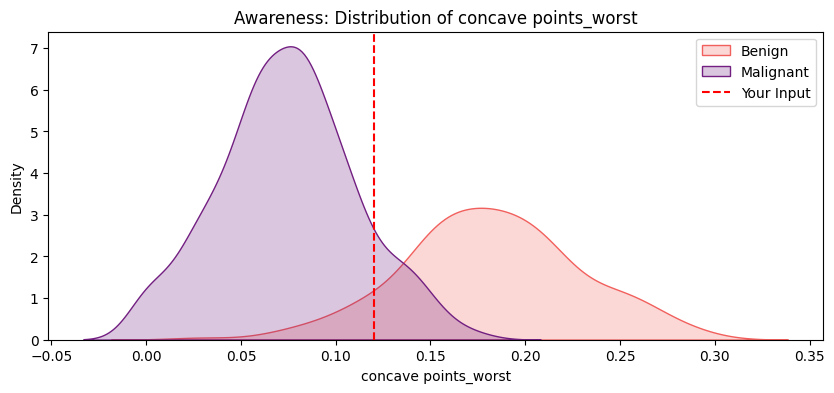

The probability of cancer is: 45.49%


c:\Users\eyad\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# for test
print(df.head()) 

show_awareness_chart(df, 'concave points_worst', 0.12)

sample_input = [0.1, 120.0, 0.08, 15.0, 90.0]
prob = predict_probability(sample_input)
print(f"The probability of cancer is: {prob:.2f}%")